In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

# Plotting options, change to your liking
sc.set_figure_params(figsize=(3, 3), frameon=False)

In [2]:
###Load Data
adata = sc.read_h5ad('/weka/labs/kzhang/kzhang-lab-scratch/blake/HKAv2/HKAv2_aPT-PT-S1-2_Subset_12172025.h5ad')
adata

AnnData object with n_obs × n_vars = 42927 × 36588
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'source', 'assay', 'experiment', 'patient', 'specimen', 'condition_level3', 'condition_level2', 'condition_level1', 'condition', 'percent_cortex', 'percent_medulla', 'region_level3', 'region_level2', 'region_level1', 'age_binned', 'sex', 'race', 'KDIGO_stage', 'baseline_eGFR_binned', 'proteinuria_binned', 'A1c_binned', 'albuminuria_binned', 'diabetes_history', 'diabetes_duration', 'hypertension_history', 'hypertension_duration', 'on_RAAS_blockade', 'ckd_stageC', 'location', 'laterality', 'protocol', 'tissue_type_full', 'tissue_type', 'v2.clusters', 'v2.subclass.full', 'v2.subclass.l3', 'v2.subclass.l2', 'v2.subclass.l1', 'v2.state.l2', 'v2.state.l1', 'v2.class', 'v2.structure'
    var: 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'data'

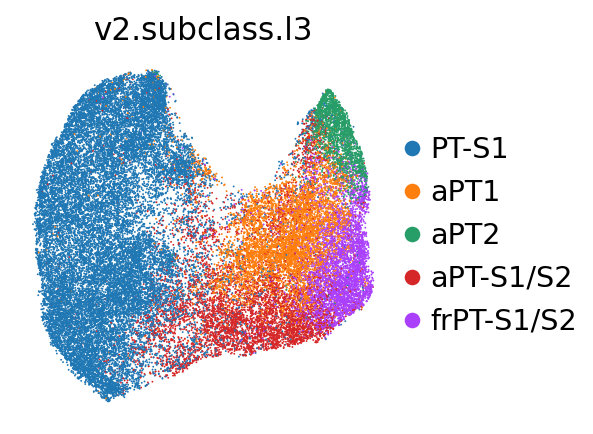

In [4]:
sc.pl.umap(adata, color=["v2.subclass.l3"], ncols=1)

In [5]:
root_celltype = "aPT2"

sc.pp.neighbors(adata, use_rep="X_pca", n_pcs=10)
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, use_rep="X_diffmap")
sc.tl.paga(adata, groups="v2.subclass.l3")
iroot = np.flatnonzero(adata.obs["v2.subclass.l3"] == root_celltype)[0]
adata.uns["iroot"] = iroot
sc.tl.dpt(adata)

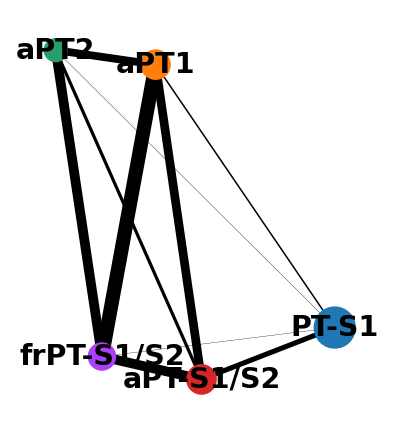

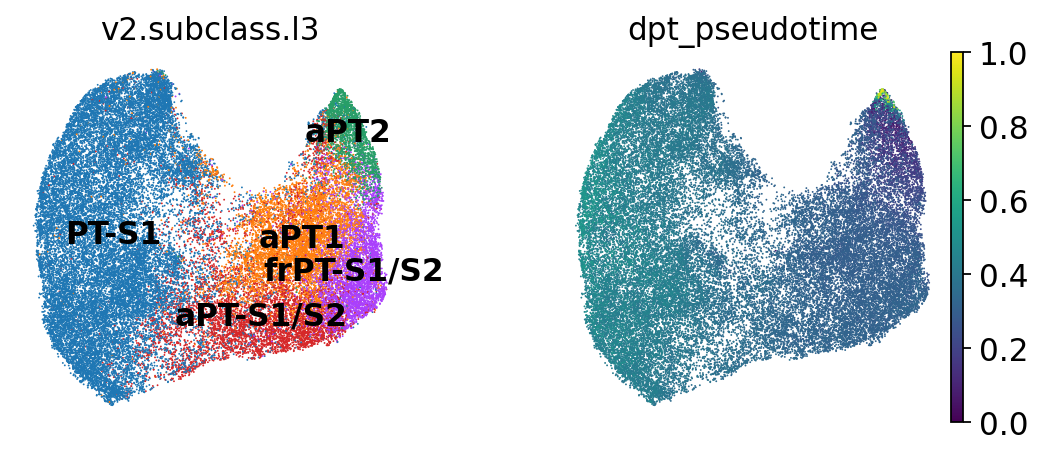

In [7]:
sc.pl.paga(adata, color=["v2.subclass.l3"],
save='PAGA_aPT-PTS1_dpt_paga.png')
sc.pl.umap(adata, color=["v2.subclass.l3", "dpt_pseudotime"], legend_loc="on data",
save='PAGA_aPT-PTS1_dpt_umap.png')

In [8]:
# read in trajectory (aPT2->PT-S1) TF-Gene interactions from scMEGA
tf_gene = pd.read_csv('/weka/blake/Projects/Human_Kidney/Atlas_V2/trajectories/aPT2-PT-S1_TF-Gene_Weight_Table.txt', sep='\t')
tf_gene

,source,target,weight
0,ARNT2,CSDC2,-0.968761
1,ARNT2,CHST9,0.964331
2,ARNT2,APBB1IP,0.962056
3,ARNT2,KCNK5,-0.958774
4,ARNT2,ANTXR1,0.954340
...,...,...,...
18495,VEZF1,LRRC28,-0.916307
18496,VEZF1,STK17A,0.915943
18497,VEZF1,IGF1R,-0.915844
18498,VEZF1,ENAH,0.915553


In [9]:
dc.mt.ulm(data=adata, net=tf_gene)

In [10]:
score = dc.pp.get_obsm(adata=adata, key="score_ulm")
score

AnnData object with n_obs × n_vars = 42927 × 37
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'source', 'assay', 'experiment', 'patient', 'specimen', 'condition_level3', 'condition_level2', 'condition_level1', 'condition', 'percent_cortex', 'percent_medulla', 'region_level3', 'region_level2', 'region_level1', 'age_binned', 'sex', 'race', 'KDIGO_stage', 'baseline_eGFR_binned', 'proteinuria_binned', 'A1c_binned', 'albuminuria_binned', 'diabetes_history', 'diabetes_duration', 'hypertension_history', 'hypertension_duration', 'on_RAAS_blockade', 'ckd_stageC', 'location', 'laterality', 'protocol', 'tissue_type_full', 'tissue_type', 'v2.clusters', 'v2.subclass.full', 'v2.subclass.l3', 'v2.subclass.l2', 'v2.subclass.l1', 'v2.state.l2', 'v2.state.l1', 'v2.class', 'v2.structure', 'dpt_pseudotime'
    uns: 'v2.subclass.l3_colors', 'neighbors', 'diffmap_evals', 'paga', 'v2.subclass.l3_sizes', 'iroot'
    obsm: 'X_pca', 'X_umap', 'X_diffmap', 'score_ulm', 'padj_ulm'

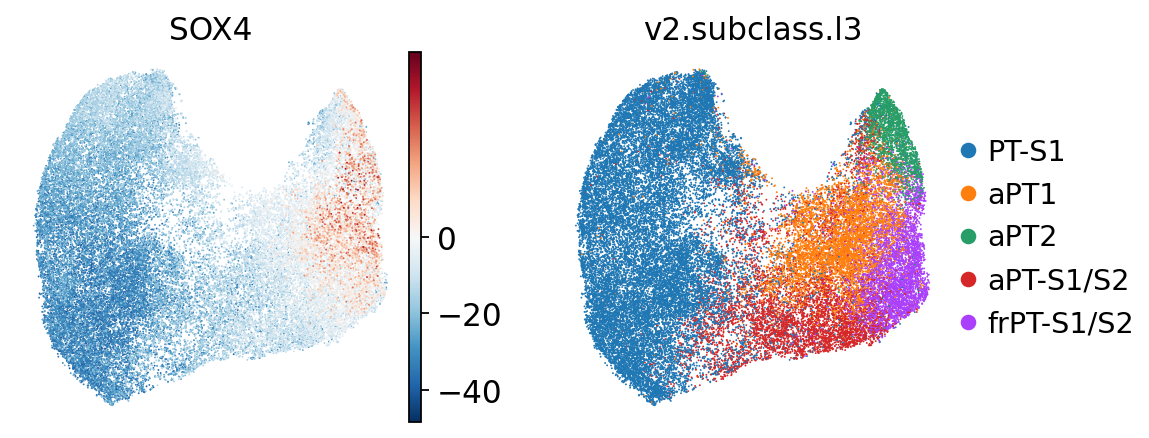

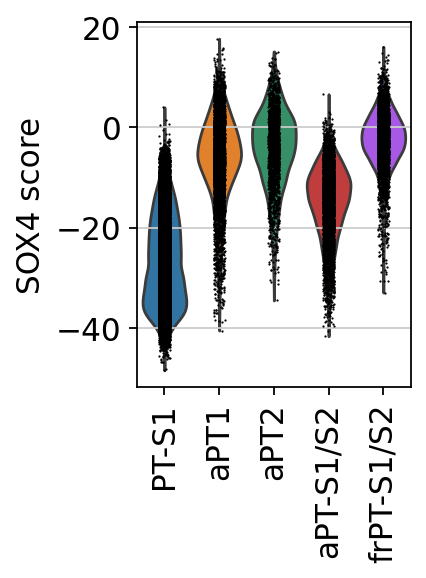

In [11]:
tf = "SOX4"
sc.pl.umap(score, color=[tf, "v2.subclass.l3"], cmap="RdBu_r", vcenter=0,
save='PAGA_aPT-PTS1_dpt_umap_SOX4.png')
sc.pl.violin(score, keys=[tf], groupby="v2.subclass.l3", rotation=90, ylabel=f"{tf} score",
save='PAGA_aPT-PTS1_dpt_umap_SOX4_violin.png')

In [12]:
tfs = dc.tl.rankby_order(
    adata=score,
    order="dpt_pseudotime",
    stat="dcor",
)
tfs

,name,stat,pval,padj
0,NR2F1,26351.026100,0.0,0.0
1,NFKB2,24514.037540,0.0,0.0
2,NFKB1,24387.591402,0.0,0.0
3,RELB,23455.833548,0.0,0.0
4,ATF3,23072.054647,0.0,0.0
5,THRB,22947.364680,0.0,0.0
6,MAF,22337.212626,0.0,0.0
7,BACH2,21635.846695,0.0,0.0
8,FOSL2,21290.590710,0.0,0.0
9,MITF,21177.995383,0.0,0.0


In [13]:
top_tfs = tfs.head(5)["name"].to_list()
top_tfs

['NR2F1', 'NFKB2', 'NFKB1', 'RELB', 'ATF3']

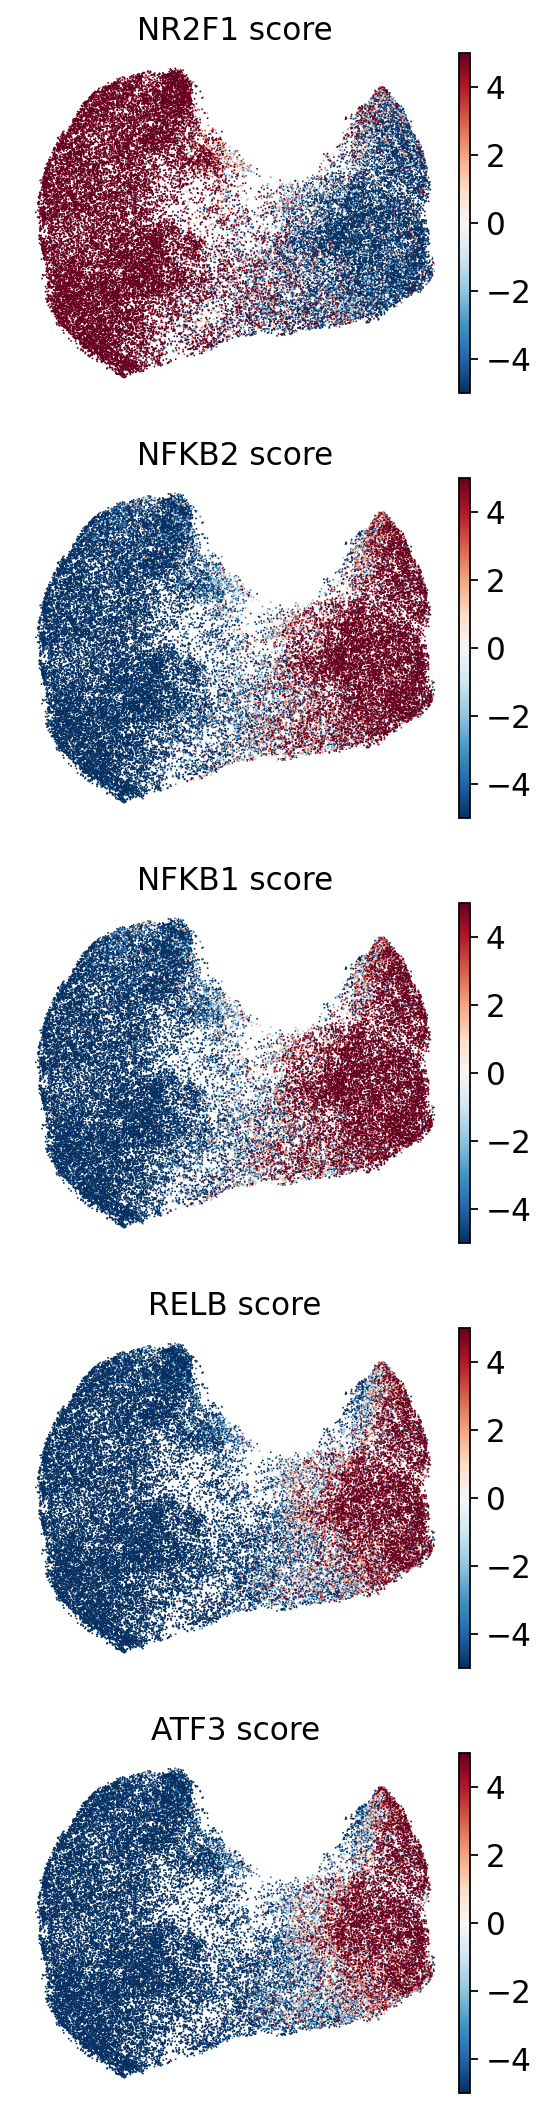

In [15]:
sc.pl.umap(score, color=top_tfs, cmap="RdBu_r", vmin=-5, vmax=5, ncols=1, title=[f"{t} score" for t in top_tfs],
save='PAGA_aPT-PTS1_dpt_umap_top_tfs.png')

In [16]:
bin_tfs = dc.pp.bin_order(
    adata=score,
    order="dpt_pseudotime",
    names=top_tfs,
    label="v2.subclass.l3",
)
bin_tfs

,name,order,value,label,color
0,NR2F1,0.005,-14.389667,aPT2,#279e68
1,NR2F1,0.005,0.288405,aPT2,#279e68
2,NR2F1,0.005,-7.417005,aPT2,#279e68
3,NR2F1,0.015,3.801348,aPT2,#279e68
4,NR2F1,0.015,-0.484305,aPT2,#279e68
...,...,...,...,...,...
214630,ATF3,0.955,3.164290,aPT2,#279e68
214631,ATF3,0.965,4.460387,aPT2,#279e68
214632,ATF3,0.965,6.060622,aPT2,#279e68
214633,ATF3,0.975,1.076956,aPT2,#279e68
